# Student Name: Isaiah Andres
# Student Number: C00286361

## Introduction:
In this notebook, a Fuzzy C Means model will be used on a land mine detection data set (link: https://archive.ics.uci.edu/dataset/763/land+mines-1). Fuzzy C Means allows for the detection of a point's degree of membership to different clusters. The dataset has features such as the voltage that an FLC sensor outputted due to magnetic distortion, the height at which the sensor was placed from the ground and the type of soil (it's unspecified on whether this is the soil that the mine may have been found in or the type of soil of which a sensor was placed on).

The Fuzzy C Means model may be able to answer the question regarding the difficulty or the practicality of classifying the types of mine based on the above features judging on the accuracy of the degree of membership that's predicted for each point.

# Importing and Finding The Optimal Parameters
The cell below shows the necessary imports made for this project as well as finding the optimal number of clusters based on their FPC (Fuzzy Partition Coefficient) which shows how cleanly a dataset would be described according to the number of clusters. After splitting the data into a training and testing set, the chart displaying the results of different C means models and their FPC values show that two cluster centres is the most ideal. However with five different features it may more suitable to choose five different centres despite the lower FPC compared to two different centres.

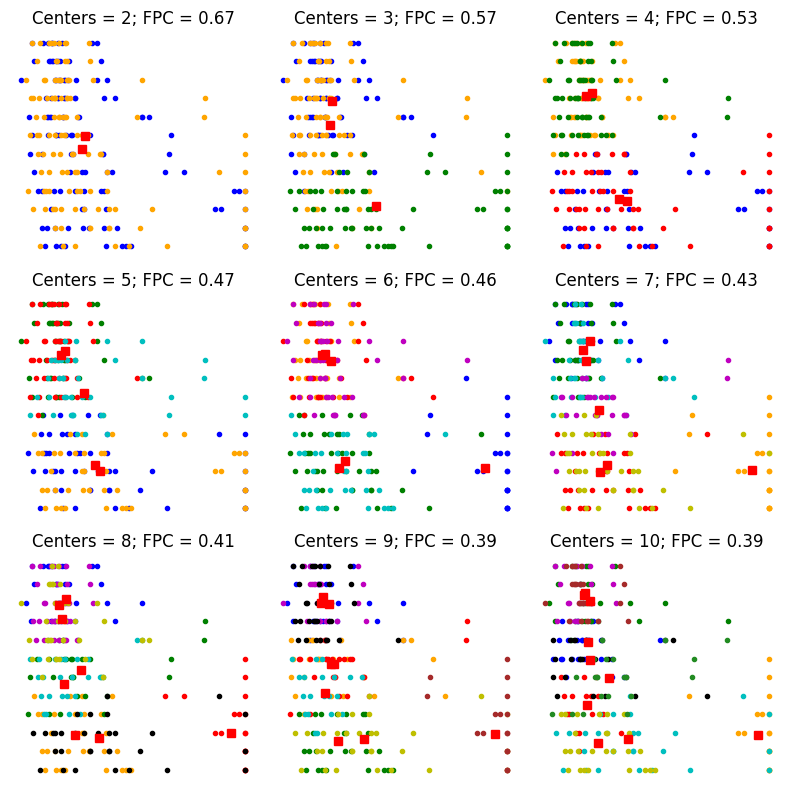

In [21]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import mode
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

colors = ['b', 'orange', 'g', 'r', 'c', 'm', 'y', 'k', 'Brown', 'ForestGreen']

landmine_dataset = pd.read_excel('Mine_Dataset.xls', sheet_name='Normalized_Data')

X = landmine_dataset[['V', 'H', 'S']]
y = landmine_dataset['M']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

alldata = X_train.values.T # Converting from pandas to numpy array and transposing due to syntax

fig1, axes1 = plt.subplots(3, 3, figsize=(8, 8))
fpcs = []

for ncenters, ax in enumerate(axes1.reshape(-1), 2):
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        alldata, ncenters, 2, error=0.005, maxiter=1000, init=None)

    fpcs.append(fpc)

    cluster_membership = np.argmax(u, axis=0)
    for j in range(ncenters):
        ax.plot(X_train.values[cluster_membership == j, 0],
                X_train.values[cluster_membership == j, 1], '.', color=colors[j])

    for pt in cntr:
        ax.plot(pt[0], pt[1], 'rs')

    ax.set_title('Centers = {0}; FPC = {1:.2f}'.format(ncenters, fpc))
    ax.axis('off')

fig1.tight_layout()

The cell below generates a graph showing how the FPC corresponds to each different number of centres.

Text(0, 0.5, 'Fuzzy partition coefficient')

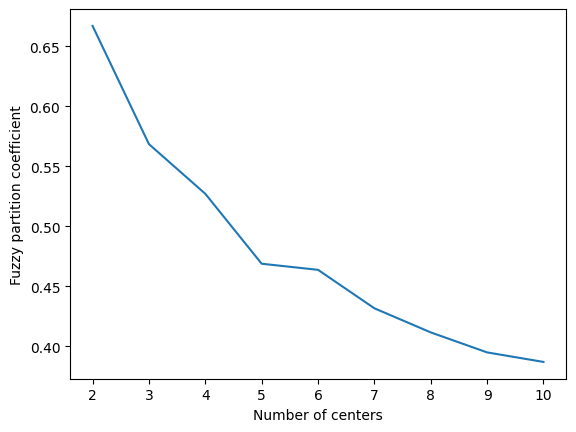

In [22]:
fig2, ax2 = plt.subplots()
ax2.plot(np.r_[2:11], fpcs)
ax2.set_xlabel("Number of centers")
ax2.set_ylabel("Fuzzy partition coefficient")

# Training The Model
The cell below shows the model being trained with 5 cluster centres and the points are plotted according to the voltage and height features. The points are clustered based on the model's highest confidence of which cluster each point should be assigned to. The graph shows how each point never seems to cluster completely given how different colour points seem to end up very close to each other such as what's seen with purple, green and blue clusters or the red and orange clusters.

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


Text(0, 0.5, 'Height (Normalised)')

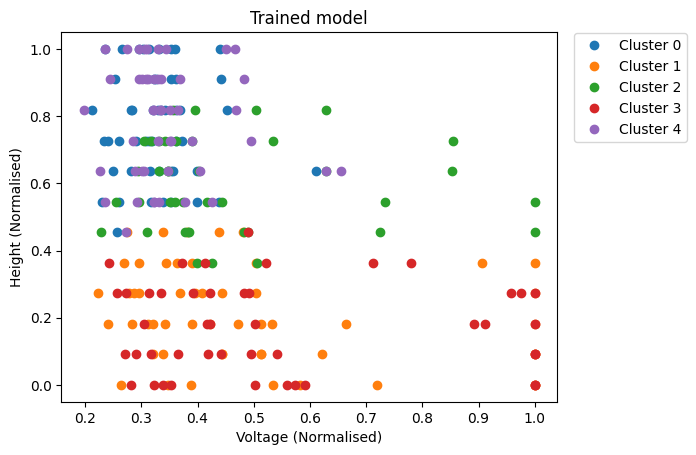

In [23]:
# Regenerate fuzzy model with 5 cluster centers - note that center ordering
# is random in this clustering algorithm, so the centers may change places
cntr, u_orig, _, _, _, _, _ = fuzz.cluster.cmeans(
    alldata, 5, 2, error=0.005, maxiter=1000)

cluster_membership = np.argmax(u_orig, axis=0)

label_map = {cluster_id: cluster_id for cluster_id in range(5)}

print(label_map)  

# Show 5-cluster model
fig2, ax2 = plt.subplots()
ax2.set_title('Trained model')
for j in range(5):
    mask = (u_orig.argmax(axis=0) == j)
    
    mine_label = label_map[j]
    
    ax2.plot(
        alldata[0, mask],
        alldata[1, mask],
        'o',
        label=f'Cluster {mine_label}'
    )
ax2.legend()
ax2.legend(loc='center left', bbox_to_anchor=(1.02, 0.85))
plt.xlabel("Voltage (Normalised)")
plt.ylabel("Height (Normalised)")

The cell below plots out the confidence that the model has in predicting each point's membership by taking the highest degree of membership of each point. Very few points show a confidence below 0.5 on the graph however the graph's prediction's on what class each point most likely belongs can still be incorrect. 

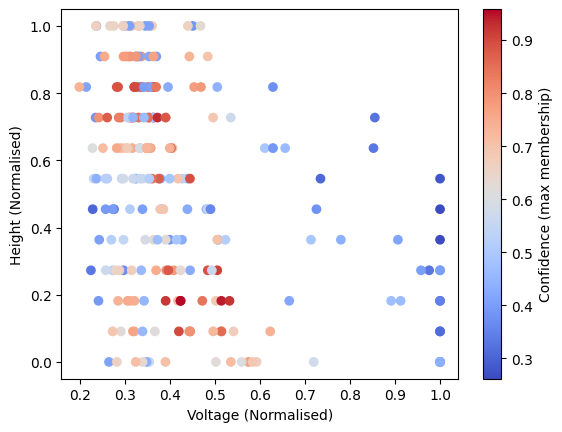

In [24]:
# Regenerate fuzzy model with 5 cluster centers - note that center ordering
# is random in this clustering algorithm, so the centers may change places
cntr, u_orig, _, _, _, _, _ = fuzz.cluster.cmeans(
    alldata, 5, 2, error=0.005, maxiter=1000)

max_membership = np.max(u_orig, axis=0)

plt.scatter(
    alldata[0],
    alldata[1],
    c=max_membership,
    cmap='coolwarm'
)
plt.xlabel("Voltage (Normalised)")
plt.ylabel("Height (Normalised)")
plt.colorbar(label='Confidence (max membership)')

# Evaluating The Model
The cell below shows the predictions made by the model and coloured based on the model's highest confidence of which each cluster a point should be assigned to, similar to what's shown in the training set.

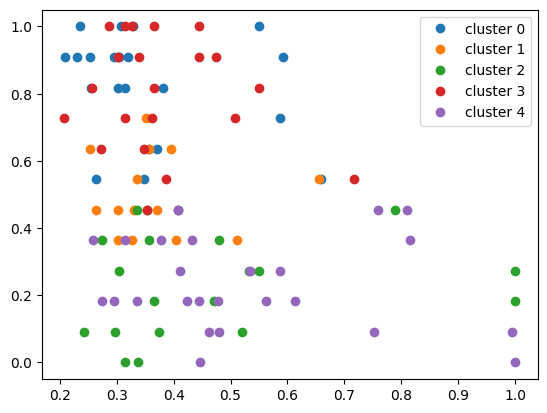

In [25]:
newdata = X_test.values.T # Converting from pandas to numpy array and converting x values into one column

u, u0, d, jm, p, fpc = fuzz.cluster.cmeans_predict(
    newdata, cntr, 5, error=0.005, maxiter=1000)

cluster_membership = np.argmax(u, axis=0) 

fig3, ax3 = plt.subplots()
ax3.set_title('')
for j in range(5):
    ax3.plot(newdata[0, u.argmax(axis=0) == j],
             newdata[1, u.argmax(axis=0) == j], 'o',
             label='cluster ' + str(j))
ax3.legend()

plt.show()

The cell below constructs a confusion matrix from the model's predictions made from the test set. The classes are retrieved by taking the predominant class used in each cluster and then added to the confusion matrix. The confusion matrix shows that the classes detected are 1 (null), 2 (Anti tank) and 3 (Anti personnel) with no predicitons made for 4 (Booby trapped anti personnel) and 5 (M14 Anti personnel). This shows that it would be quite difficult to classify the exact type of landmine because of how often predictions are made for no landmines despite their presence due to fact that the model can't cleanly seperate the classes into their own clusters with the given features of the voltage, sensor height and soil.

[3 1 1 2 3 3 1 1 3 1 3 1 2 3 1 3 1 1 2 3 1 3 1 1 2 2 1 1 1 1 2 2 1 2 1 3 1
 3 1 2 3 1 1 2 1 1 1 1 1 2 3 1 3 3 1 1 1 1 2 1 2 2 1 2 3 3 2 1 1 1 3 2 1 2
 3 1 2 1 1 1 1 3 1 1 1 3 1 2 1 1 3 3 1 1 3 1 3 2 1 2 1 1]
[[16  3  4  0  0]
 [ 9  6  5  0  0]
 [11  6  8  0  0]
 [10  2  3  0  0]
 [ 9  5  5  0  0]]


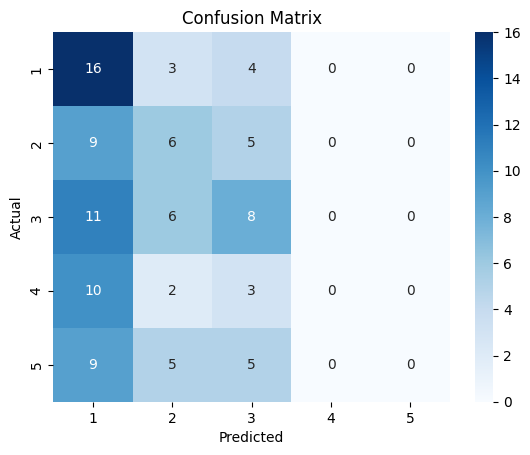

In [26]:
cluster_membership = np.argmax(u, axis=0)

cluster_to_class = {}

for cluster in range(5):
    mask = (cluster_membership == cluster)
    
    if np.any(mask):
        cluster_to_class[cluster] = mode(y_test.values[mask], keepdims=True)[0][0]

y_pred = np.array([cluster_to_class[c] for c in cluster_membership])
print(y_pred)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=[1,2,3,4,5])
print(cm)

# Plot heatmap with correct tick labels
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Conclusion
In conclusion, the confusion matrix based on the test set shows that many predictions are for the lack of a mine's presence and no correct predictions for mines 4 (booby trapped anti-personel) and 5 (M14 anti personel) with some incorrect predictions for mines 2 (anti tank) and 3 (anti personel). This may support the fact that the features of soil, sensor height, and voltage are not reliable for predicting the type of mine detected due to the misclassifications caused by ambiguous degree of membership on unseen data.  